In [24]:
import yfinance as yf
import pandas as pd
import os
import talib
import matplotlib.pyplot as plt

# Create the directory if it doesn't exist
os.makedirs('../data/raw', exist_ok=True)

# Download sample data for Task 2
ticker = "TSLA"
df = yf.download(ticker, start="2020-01-01", end="2024-01-01")

# --- IMPORTANT FIX ---
# If yfinance returns a MultiIndex (common in 2024+), flatten it
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Save it
df.to_csv('../data/raw/stock_prices.csv')
print(f"✅ Downloaded {ticker} data and saved to data/raw/stock_prices.csv")

[*********************100%***********************]  1 of 1 completed

✅ Downloaded TSLA data and saved to data/raw/stock_prices.csv


Load the saved data and verify

In [19]:
df_stock = pd.read_csv('../data/raw/stock_prices.csv', parse_dates=['Date'], index_col='Date')

# Check for missing values (Requirement: "Handle missing values")
print(f"Missing values before: \n{df_stock.isnull().sum()}")
df_stock = df_stock.ffill() # Forward fill any gaps

# Preview
df_stock.head()

Missing values before: 
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


Technical Indicators

In [20]:
# Ensure the data is sorted by date
df_stock = df_stock.sort_index()

# Calculate indicators
df_stock['SMA_20'] = talib.SMA(df_stock['Close'], timeperiod=20)
df_stock['RSI'] = talib.RSI(df_stock['Close'], timeperiod=14)
macd, macdsignal, macdhist = talib.MACD(df_stock['Close'], fastperiod=12, slowperiod=26, signalperiod=9)

df_stock['MACD'] = macd
df_stock['MACD_Signal'] = macdsignal

print("Indicators calculated successfully!")
df_stock.tail() # Look at the end of the data to see the new columns

Indicators calculated successfully!


,Close,High,Low,Open,Volume,SMA_20,RSI,MACD,MACD_Signal
Date,,,,,,,,,
2023-12-22,252.539993,258.220001,251.369995,256.760010,93370100,244.503500,58.137456,5.223831,4.421231
2023-12-26,256.609985,257.970001,252.910004,254.490005,86892400,245.529999,60.824035,5.495890,4.636162
2023-12-27,261.440002,263.339996,257.519989,258.350006,106494400,246.265999,63.793639,6.031711,4.915272
2023-12-28,253.179993,265.130005,252.710007,263.660004,113619900,246.717999,55.978815,5.723858,5.076989
2023-12-29,248.479996,255.190002,247.429993,255.100006,100891600,247.137998,52.070118,5.042505,5.070092


Apply PyNance for Financial Metrics

In [26]:
import numpy as np

# 1. Calculate Daily Returns (Percentage change day-over-day)
# This is a core financial metric showing daily gain/loss
df_stock['Daily_Return'] = df_stock['Close'].pct_change()

# 2. Calculate Log Returns 
# Often used in quantitative finance for better statistical properties
df_stock['Log_Return'] = np.log(df_stock['Close'] / df_stock['Close'].shift(1))

# 3. 20-Day Rolling Volatility
# Measures how much the price 'swings' over a 20-day window
df_stock['Volatility_20d'] = df_stock['Daily_Return'].rolling(window=20).std()

# 4. Annualized Volatility calculation
# Provides a standard risk metric (Daily Std Dev * Sqrt of trading days)
ann_vol = df_stock['Daily_Return'].std() * np.sqrt(252)

print(f"Analysis Complete.")
print(f"Average Annualized Volatility: {ann_vol:.2%}")
df_stock[['Close', 'Daily_Return', 'Volatility_20d']].tail()

Analysis Complete.
Average Annualized Volatility: 68.10%


,Close,Daily_Return,Volatility_20d
Date,,,
2023-12-22,252.539993,-0.007701,0.021398
2023-12-26,256.609985,0.016116,0.021574
2023-12-27,261.440002,0.018822,0.019685
2023-12-28,253.179993,-0.031594,0.020975
2023-12-29,248.479996,-0.018564,0.021070


Create the Final Visualizations

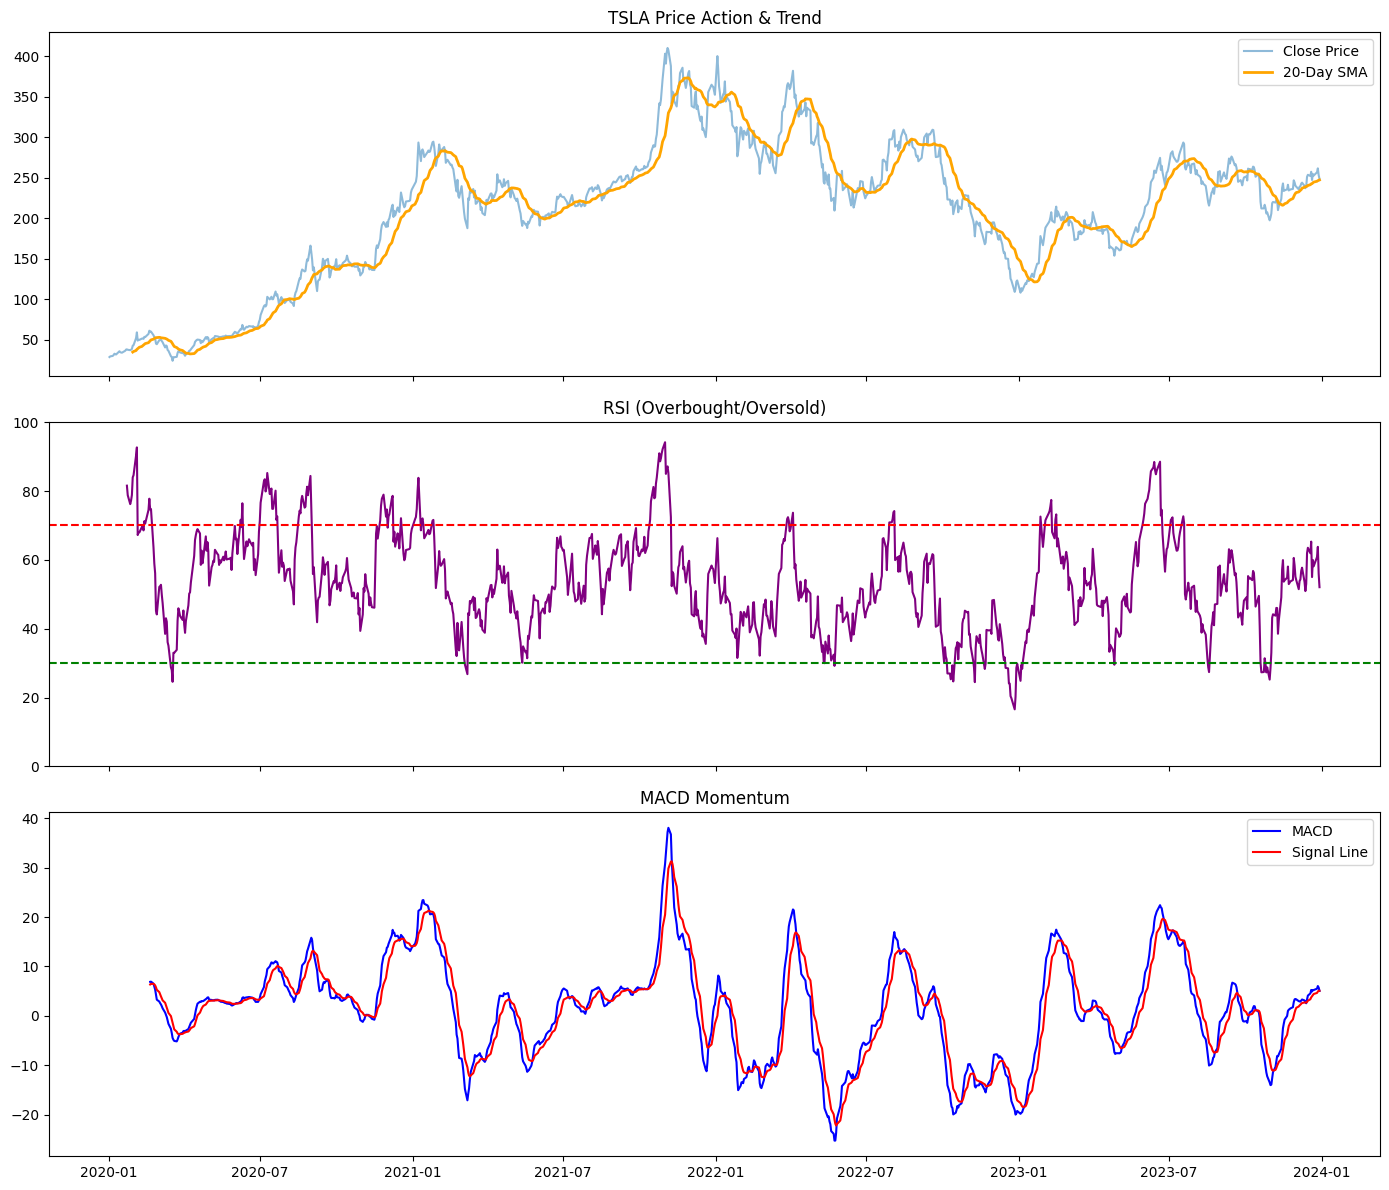

In [22]:
# Create a figure with 3 subplots (Price, RSI, MACD)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Price and SMA
ax1.plot(df_stock.index, df_stock['Close'], label='Close Price', alpha=0.5)
ax1.plot(df_stock.index, df_stock['SMA_20'], label='20-Day SMA', color='orange', linewidth=2)
ax1.set_title('TSLA Price Action & Trend')
ax1.legend()

# Panel 2: RSI (Momentum)
ax2.plot(df_stock.index, df_stock['RSI'], label='RSI', color='purple')
ax2.axhline(70, color='red', linestyle='--') # Overbought threshold
ax2.axhline(30, color='green', linestyle='--') # Oversold threshold
ax2.set_title('RSI (Overbought/Oversold)')
ax2.set_ylim(0, 100)

# Panel 3: MACD (Momentum Shift)
ax3.plot(df_stock.index, df_stock['MACD'], label='MACD', color='blue')
ax3.plot(df_stock.index, df_stock['MACD_Signal'], label='Signal Line', color='red')
ax3.set_title('MACD Momentum')
ax3.legend()

plt.tight_layout()
plt.show()